# Estimador da Máxima Verossimilhança (MLE)

Este notebook demonstra como aplicar o princípio da Máxima Verossimilhança (MLE) para estimar os parâmetros de uma distribuição de probabilidade a partir de dados observados.

**Objetivo:** Gerar dados de uma distribuição Normal com parâmetros $\mu$ e $\sigma$ conhecidos e, em seguida, usar a MLE para estimar esses parâmetros e verificar se nossas estimativas se aproximam dos valores verdadeiros.

Abordaremos duas formas:
1.  **Solução Analítica:** Implementando a fórmula fechada para os estimadores MLE da média e do desvio padrão.
2.  **Otimização Numérica:** Maximizando a função de Log-Verossimilhança (ou, de forma equivalente, minimizando a Log-Verossimilhança Negativa), uma abordagem mais geral que funciona para modelos complexos.

### Importação de Bibliotecas

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# Estilo para os gráficos
plt.style.use("seaborn-v0_8-whitegrid")

### Geração de Dados Sintéticos

Vamos criar um conjunto de dados a partir de uma distribuição Normal com uma média e desvio padrão que definiremos. Nosso objetivo será "esquecer" esses valores e tentar recuperá-los usando MLE.

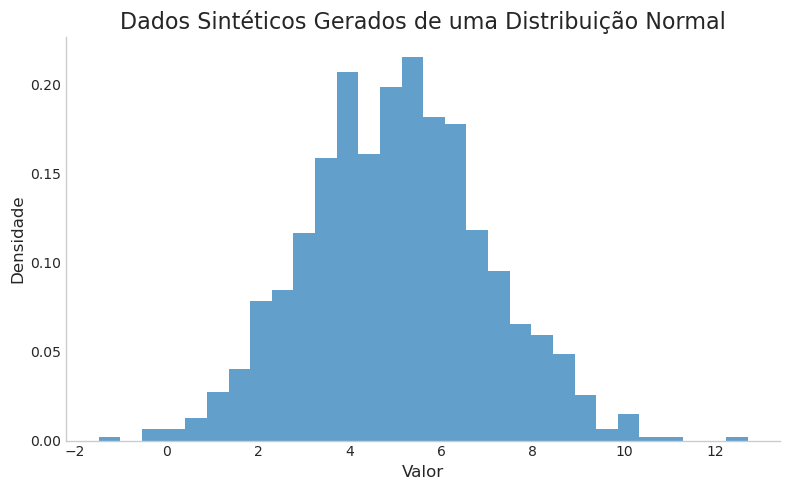

In [10]:
# Parâmetros verdadeiros da nossa população
mu_real = 5.0
sigma_real = 2.0
n_samples = 1000  # Tamanho da nossa amostra

# Geração dos dados sintéticos
np.random.seed(42)  # Para reprodutibilidade
dados = np.random.normal(loc=mu_real, scale=sigma_real, size=n_samples)

# Visualização dos dados gerados
plt.figure(figsize=(8, 5))
plt.hist(dados, bins=30, density=True, alpha=0.7)
plt.title("Dados Sintéticos Gerados de uma Distribuição Normal", fontsize=16)
plt.xlabel("Valor", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

### Abordagem 1: Solução Analítica

Para a distribuição Normal, as fórmulas para os estimadores de máxima verossimilhança da média ($\mu$) e do desvio padrão ($\sigma$) são conhecidas e simples:

$$ \hat{\mu}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} x_i = \bar{x} $$
$$ \hat{\sigma}_{MLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2} $$

Note que o estimador para a variância (o termo dentro da raiz) usa $n$ no denominador, o que o torna um estimador enviesado (biased) para amostras finitas, mas consistente.

In [11]:
# Cálculo das estimativas via MLE analítico
mu_mle_analitico = np.mean(dados)
sigma_mle_analitico = np.std(dados)  # np.std calcula com 'n' por padrão

print(f"Parâmetros Reais:     mu = {mu_real:.4f}, sigma = {sigma_real:.4f}")
print(
    f"Estimativas MLE (Analítica): mu = {mu_mle_analitico:.4f}, sigma = {sigma_mle_analitico:.4f}"
)

Parâmetros Reais:     mu = 5.0000, sigma = 2.0000
Estimativas MLE (Analítica): mu = 5.0387, sigma = 1.9575


Como podemos ver, as estimativas são muito próximas dos valores reais, como esperado.

### Abordagem 2: Otimização Numérica

Esta é a abordagem mais geral. Funciona mesmo quando não temos uma fórmula analítica. O processo é:

1.  **Definir a Função de Log-Verossimilhança (Log-Likelihood):** É a soma dos logaritmos da função de densidade de probabilidade (PDF) avaliada em cada ponto de dado.
2.  **Maximizar essa função:** Como os otimizadores padrão são projetados para *minimizar* funções, nós vamos **minimizar a log-verossimilhança negativa**.

Para uma distribuição Normal, a log-verossimilhança é:
$$ \ell(\mu, \sigma | \mathbf{x}) = \sum_{i=1}^{n} \log \left( \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x_i - \mu)^2}{2\sigma^2}} \right) $$

In [12]:
# Define a função de log-verossimilhança negativa
def log_verossimilhança_negativa(params, data):
    """
    Calcula a log-verossimilhança negativa para uma distribuição Normal.
    params: uma lista ou tupla [mu, sigma]
    data: os dados observados
    """
    mu, sigma = params[0], params[1]

    # Condição para evitar sigma <= 0, que é inválido
    if sigma <= 0:
        return np.inf  # Retorna infinito se o parâmetro for inválido

    # Usar a função logpdf da SciPy é numericamente estável e eficiente
    log_likelihood = np.sum(norm.logpdf(data, loc=mu, scale=sigma))

    # Retornamos o negativo porque queremos minimizar
    return -log_likelihood

In [13]:
# Realiza a otimização
# Chute inicial para os parâmetros [mu, sigma]
chute_inicial = [0.0, 1.0]

# Limites para os parâmetros (sigma > 0)
bounds = [(None, None), (1e-6, None)]

resultado_otimizacao = minimize(
    log_verossimilhança_negativa,
    x0=chute_inicial,
    args=(dados,),
    method="L-BFGS-B",  # Um bom método de otimização quasi-Newton que aceita limites
    bounds=bounds,
)

# Extrai os parâmetros otimizados
mu_mle_numerico, sigma_mle_numerico = resultado_otimizacao.x

print(f"Parâmetros Reais:     mu = {mu_real:.4f}, sigma = {sigma_real:.4f}")
print(
    f"Estimativas MLE (Numérica): mu = {mu_mle_numerico:.4f}, sigma = {sigma_mle_numerico:.4f}"
)

Parâmetros Reais:     mu = 5.0000, sigma = 2.0000
Estimativas MLE (Numérica): mu = 5.0387, sigma = 1.9575


Novamente, os resultados da otimização numérica são praticamente idênticos aos da solução analítica e muito próximos dos valores reais.

### Conclusão e Visualização Final

Vamos plotar o histograma dos dados junto com as PDFs das distribuições Normal usando os parâmetros reais, os estimados pela solução analítica e os estimados pela otimização numérica. Elas devem se sobrepor quase perfeitamente.

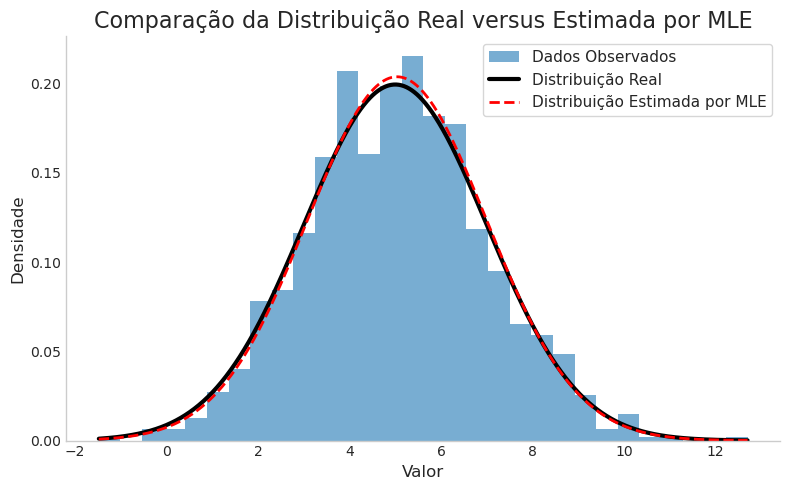

In [14]:
plt.figure(figsize=(8, 5))

# Histograma dos dados
plt.hist(dados, bins=30, density=True, alpha=0.6, label="Dados Observados")

# PDF com parâmetros reais
x = np.linspace(min(dados), max(dados), 1000)
pdf_real = norm.pdf(x, loc=mu_real, scale=sigma_real)
plt.plot(x, pdf_real, "k-", lw=3, label="Distribuição Real")

# PDF com estimativas MLE (analítica e numérica são quase idênticas)
pdf_mle = norm.pdf(x, loc=mu_mle_numerico, scale=sigma_mle_numerico)
plt.plot(x, pdf_mle, "r--", lw=2, label="Distribuição Estimada por MLE")

plt.title("Comparação da Distribuição Real versus Estimada por MLE", fontsize=16)
plt.xlabel("Valor", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

O gráfico final mostra um ajuste excelente, confirmando que ambas as abordagens da Máxima Verossimilhança foram capazes de encontrar os parâmetros que melhor descrevem os dados observados.